### Aim of the Experiment:
1. To understand how RNN processes text as sequential data.
2. To create input-output context-target pairs from text for next-word prediction.
3. To train a SimpleRNN model using tokenized text sequences.
4. To evaluate learning using loss, Top-1 accuracy, and Top-5 accuracy graphs.
5. To test next-word prediction using different seed phrases across:
   - **Part A:** Custom sentence corpus
   - **Part B:** Shakespeare text corpus

## 0. Import Required Libraries

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Part A: Custom Sentences Dataset
First implementation with no external dataset for debugging tokenization, padding, architecture, and top-k predictions.

### Step A1: Define Custom Training Sentences

In [4]:
training_sentences = [
    "students learn natural language processing",
    "students study natural language processing",
    "natural language processing includes text classification",
    "natural language processing includes next word prediction",
    "recurrent neural network predicts the next word",
    "the model predicts the next word",
    "the model learns word order",
    "students write python code",
    "the teacher demonstrates next word prediction",
    "the tokenizer converts words into token identifiers"
]

validation_sentences = [
    "students test next word prediction",
    "natural language processing uses neural networks",
    "the model learns from input sequences"
]

print("Training sentences:", len(training_sentences))
print("Validation sentences:", len(validation_sentences))

Training sentences: 10
Validation sentences: 3


### Step A2: Clean Text and Build Vocabulary

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

training_sentences = [clean_text(s) for s in training_sentences]
validation_sentences = [clean_text(s) for s in validation_sentences]

tokenizer = Tokenizer(oov_token="<OOV>", lower=True)
tokenizer.fit_on_texts(training_sentences)

vocab_size = len(tokenizer.word_index) + 1
index_to_word = {idx: word for word, idx in tokenizer.word_index.items()}

print("Vocabulary size:", vocab_size)
print("Sample word to index mapping:", dict(list(tokenizer.word_index.items())[:8]))

Vocabulary size: 33
Sample word to index mapping: {'<OOV>': 1, 'the': 2, 'word': 3, 'natural': 4, 'language': 5, 'processing': 6, 'next': 7, 'students': 8}


### Step A3: Create Context-Target Pairs

In [6]:
MAX_CONTEXT_WORDS = 6
MAX_SEQUENCE_LEN = MAX_CONTEXT_WORDS + 1
CONTEXT_LENGTHS = (1, 2, 3, MAX_CONTEXT_WORDS)

def create_next_word_examples(sentences):
    sequences = []
    for sentence in sentences:
        token_ids = tokenizer.texts_to_sequences([sentence])[0]
        if len(token_ids) < 2:
            continue
        for target_pos in range(1, len(token_ids)):
            lengths = {min(c, target_pos) for c in CONTEXT_LENGTHS}
            for L in lengths:
                sequences.append(token_ids[target_pos - L : target_pos + 1])
    
    padded = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LEN, padding="pre", truncating="pre")
    X = padded[:, :-1]
    y = padded[:, -1]
    return X.astype("int32"), y.astype("int32")

X_train, y_train = create_next_word_examples(training_sentences)
X_val, y_val = create_next_word_examples(validation_sentences)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Number of training pairs:", len(X_train))

X_train shape: (132, 6)
y_train shape: (132,)
Number of training pairs: 132


### Step A4: Build and Compile the SimpleRNN Model

In [8]:
model = Sequential([
    Input(shape=(MAX_CONTEXT_WORDS,), name="input_context"),
    Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True, name="word_embedding"),
    SimpleRNN(128, activation="tanh", dropout=0.10, name="simple_rnn"),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(vocab_size, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="top1_accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)      │ (None, 6, 64)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,217 (145.38 KB)

 Trainable params: 37,217 (145.38 KB)

 Non-trainable params: 0 (0.00 B)

### Step A5: Train and Evaluate the Model

In [10]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

results = model.evaluate(X_val, y_val, return_dict=True)
print("\nEvaluation Results on Validation Data:", results)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.9318 - top1_accuracy: 0.4091 - top5_accuracy: 0.7652 - val_loss: 3.3755 - val_top1_accuracy: 0.2632 - val_top5_accuracy: 0.3158 - learning_rate: 2.5000e-04
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.8818 - top1_accuracy: 0.4091 - top5_accuracy: 0.8409 - val_loss: 3.3823 - val_top1_accuracy: 0.2368 - val_top5_accuracy: 0.3158 - learning_rate: 2.5000e-04
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.8043 - top1_accuracy: 0.4242 - top5_accuracy: 0.8182 - val_loss: 3.4001 - val_top1_accuracy: 0.2368 - val_top5_accuracy: 0.3158 - learning_rate: 2.5000e-04
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.7135 - top1_accuracy: 0.4167 - top5_accuracy: 0.7727 - val_loss: 3.4238 - val_top1_accuracy: 0.2368 - val_top5_accuracy: 0.3158 - learning_rate: 2.5000e-04
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.6791 - top1_accuracy: 0.4242 - top5_accuracy: 0.7879 - val_loss: 3.4429 - va

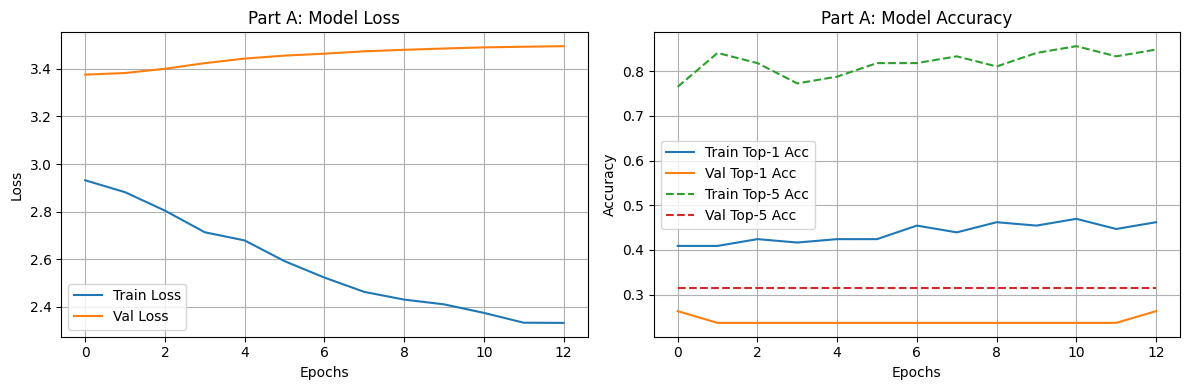

In [11]:
# Plotting Training and Validation Loss & Accuracy curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Part A: Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['top1_accuracy'], label='Train Top-1 Acc')
plt.plot(history.history['val_top1_accuracy'], label='Val Top-1 Acc')
plt.plot(history.history['top5_accuracy'], label='Train Top-5 Acc', linestyle='--')
plt.plot(history.history['val_top5_accuracy'], label='Val Top-5 Acc', linestyle='--')
plt.title('Part A: Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Step A6: Predict Top-5 Next Words

In [12]:
def predict_top_k_words(seed_text, top_k=5):
    cleaned_seed = clean_text(seed_text)
    token_ids = tokenizer.texts_to_sequences([cleaned_seed])[0]
    if not token_ids:
        raise ValueError("Seed phrase has no known words.")
    
    token_ids = token_ids[-MAX_CONTEXT_WORDS:]
    model_input = pad_sequences([token_ids], maxlen=MAX_CONTEXT_WORDS, padding="pre", truncating="pre")
    
    probs = model.predict(model_input, verbose=0)[0]
    ranked = np.argsort(probs)[::-1]
    
    predictions = []
    for idx in ranked:
        word = index_to_word.get(int(idx))
        if idx == 0 or word is None or word == "<OOV>":
            continue
        predictions.append((word, float(probs[idx])))
        if len(predictions) == top_k:
            break
    return predictions

# Test seed phrases
seed_phrases = ["natural language", "recurrent neural", "next word", "the model"]
for seed in seed_phrases:
    print(f"\nSeed: '{seed}'")
    top_predictions = predict_top_k_words(seed, top_k=5)
    for word, prob in top_predictions:
        print(f"  --> {word:15s} (prob: {prob:.4f})")


Seed: 'natural language'
  --> processing      (prob: 0.0888)
  --> next            (prob: 0.0681)
  --> word            (prob: 0.0441)
  --> prediction      (prob: 0.0433)
  --> model           (prob: 0.0355)

Seed: 'recurrent neural'
  --> next            (prob: 0.0482)
  --> word            (prob: 0.0395)
  --> classification  (prob: 0.0339)
  --> predicts        (prob: 0.0335)
  --> processing      (prob: 0.0334)

Seed: 'next word'
  --> prediction      (prob: 0.0809)
  --> next            (prob: 0.0613)
  --> word            (prob: 0.0611)
  --> processing      (prob: 0.0384)
  --> model           (prob: 0.0362)

Seed: 'the model'
  --> word            (prob: 0.0586)
  --> next            (prob: 0.0513)
  --> prediction      (prob: 0.0425)
  --> predicts        (prob: 0.0341)
  --> processing      (prob: 0.0339)


# Part B: Shakespeare Dataset
Second implementation applying the same RNN workflow on a larger real-world plain-text corpus.

### Step B1: Download Shakespeare Text Corpus

In [14]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
path_to_file = tf.keras.utils.get_file("shakespeare.txt", url)

with open(path_to_file, "r", encoding="utf-8") as file:
    raw_text = file.read()

print("Total characters:", len(raw_text))
print("\n--- Dataset sample ---\n")
print(raw_text[:100])

Total characters: 1115394

--- Dataset sample ---

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


### Step B2: Clean Lines and Build Vocabulary

In [15]:
def clean_line(line):
    line = line.lower()
    line = re.sub(r"[^a-z' ]+", " ", line)
    line = re.sub(r"\s+", " ", line).strip()
    return line

cleaned_lines = [clean_line(line) for line in raw_text.splitlines()]
cleaned_lines = [line for line in cleaned_lines if len(line.split()) >= 2]

NUM_LINES = 15000  # use None for full corpus
selected_lines = cleaned_lines if NUM_LINES is None else cleaned_lines[:NUM_LINES]

train_lines, val_lines = train_test_split(
    selected_lines, test_size=0.15, random_state=42
)

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_lines)
vocab_size = min(5000, len(tokenizer.word_index) + 1)

print(f"Training lines: {len(train_lines)}, Validation lines: {len(val_lines)}")
print("Vocabulary size:", vocab_size)

Training lines: 12750, Validation lines: 2250
Vocabulary size: 5000


### Step B3: Create Shakespeare Context-Target Pairs

In [16]:
MAX_CONTEXT_WORDS = 7
MAX_SEQUENCE_LEN = MAX_CONTEXT_WORDS + 1
CONTEXT_LENGTHS = (1, 2, 4, MAX_CONTEXT_WORDS)

def make_examples(lines):
    sequences = []
    for line in lines:
        ids = tokenizer.texts_to_sequences([line])[0]
        ids = [i for i in ids if 0 < i < vocab_size]
        if len(ids) < 2:
            continue
        for target_pos in range(1, len(ids)):
            lengths = {min(c, target_pos) for c in CONTEXT_LENGTHS}
            for L in lengths:
                sequences.append(ids[target_pos - L : target_pos + 1])
    
    padded = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LEN, padding="pre", truncating="pre")
    X = padded[:, :-1]
    y = padded[:, -1]
    return X.astype("int32"), y.astype("int32")

X_train, y_train = make_examples(train_lines)
X_val, y_val = make_examples(val_lines)

print("Shakespeare X_train shape:", X_train.shape)
print("Shakespeare y_train shape:", y_train.shape)

Shakespeare X_train shape: (231952, 7)
Shakespeare y_train shape: (231952,)


### Step B4: Train SimpleRNN on Shakespeare

In [21]:
model = Sequential([
    Input(shape=(MAX_CONTEXT_WORDS,)),
    Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),
    SimpleRNN(128, activation="tanh"),
    Dropout(0.25),
    Dense(vocab_size, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy")
    ]
)

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=512,
    callbacks=[early_stop]
)

Epoch 1/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.0392 - loss: 6.7776 - top5_accuracy: 0.1356 - val_accuracy: 0.0704 - val_loss: 6.2086 - val_top5_accuracy: 0.1776
Epoch 2/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.0647 - loss: 6.1555 - top5_accuracy: 0.1741 - val_accuracy: 0.0964 - val_loss: 5.8589 - val_top5_accuracy: 0.2257
Epoch 3/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.0907 - loss: 5.7739 - top5_accuracy: 0.2248 - val_accuracy: 0.1031 - val_loss: 5.7400 - val_top5_accuracy: 0.2426
Epoch 4/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.1037 - loss: 5.5360 - top5_accuracy: 0.2505 - val_accuracy: 0.1055 - val_loss: 5.6960 - val_top5_accuracy: 0.2527
Epoch 5/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.1122 - loss: 5.3522 - top5_accuracy: 0.2668 - val_accuracy: 0.1074 - val_loss: 5.6810 - val_top5_accuracy: 0.2565
Epoch 6/30
454/454 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.1206 - loss: 5.1923 - 

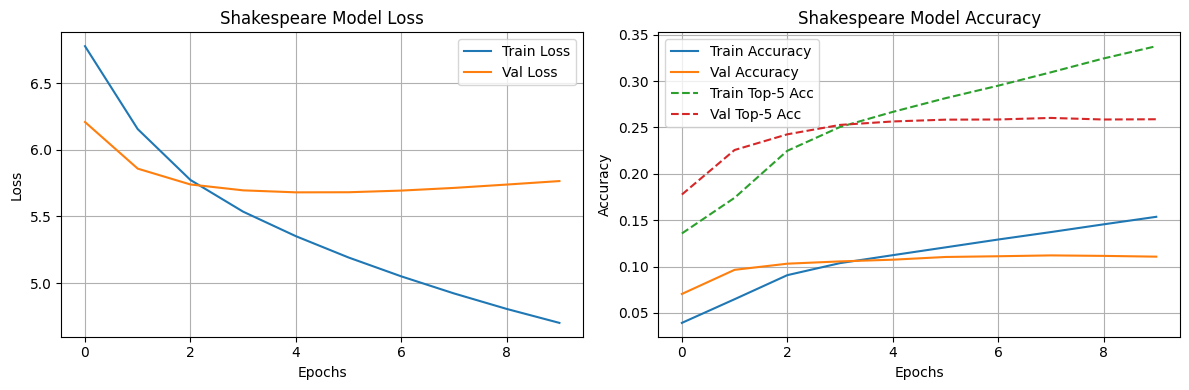

In [22]:
# Plotting Shakespeare Training and Validation Curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Shakespeare Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.plot(history.history['top5_accuracy'], label='Train Top-5 Acc', linestyle='--')
plt.plot(history.history['val_top5_accuracy'], label='Val Top-5 Acc', linestyle='--')
plt.title('Shakespeare Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Step B5: Prediction Function for Shakespeare

In [23]:
index_to_word = {idx: word for word, idx in tokenizer.word_index.items()}

def predict_next_word(seed_text, top_k=5):
    cleaned_seed = clean_line(seed_text)
    token_list = tokenizer.texts_to_sequences([cleaned_seed])[0]
    token_list = [i for i in token_list if 0 < i < vocab_size]
    
    if not token_list:
        raise ValueError("Seed phrase contains no known vocabulary words.")
    
    token_list = token_list[-MAX_CONTEXT_WORDS:]
    token_list = pad_sequences([token_list], maxlen=MAX_CONTEXT_WORDS, padding="pre", truncating="pre")
    
    probs = model.predict(token_list, verbose=0)[0]
    ranked = np.argsort(probs)[::-1]
    
    predictions = []
    for idx in ranked:
        word = index_to_word.get(int(idx))
        if idx == 0 or word is None or word == "<OOV>":
            continue
        predictions.append((word, float(probs[idx])))
        if len(predictions) == top_k:
            break
    return predictions

# Test Shakespeare seed phrases
test_seeds = ["to be or not", "my lord", "the king", "i will"]
for seed in test_seeds:
    print(f"\nSeed: '{seed}'")
    top_predictions = predict_next_word(seed, top_k=5)
    for word, prob in top_predictions:
        print(f"  --> {word:15s} (prob: {prob:.4f})")


Seed: 'to be or not'
  --> to              (prob: 0.0367)
  --> in              (prob: 0.0330)
  --> so              (prob: 0.0297)
  --> for             (prob: 0.0249)
  --> a               (prob: 0.0212)

Seed: 'my lord'
  --> of              (prob: 0.0583)
  --> and             (prob: 0.0575)
  --> is              (prob: 0.0501)
  --> my              (prob: 0.0454)
  --> the             (prob: 0.0337)

Seed: 'the king'
  --> of              (prob: 0.2777)
  --> is              (prob: 0.0559)
  --> o'              (prob: 0.0281)
  --> richard         (prob: 0.0220)
  --> that            (prob: 0.0201)

Seed: 'i will'
  --> not             (prob: 0.1406)
  --> be              (prob: 0.0845)
  --> you             (prob: 0.0371)
  --> i               (prob: 0.0294)
  --> have            (prob: 0.0259)
